# Verification of Hyperparameter Search Setup

This notebook runs the verification step of the hyperparameter search to ensure that the default parameters produce reasonable results.

In [1]:
%load_ext autoreload
%autoreload 2

In [30]:
import numpy as np
import logging
import sys
from pathlib import Path
import torch
from pprint import pprint


import matplotlib.pyplot as plt
import diffmeshopt.opt2d.hyperparameter_search as hps
from diffmeshopt.opt2d.hyperparameter_search import ExperimentRunner
import diffmeshopt.opt2d.evaluation as evaluation
from diffmeshopt.opt2d import vis

# Configure logging to stdout
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)

In [3]:
# Define paths
dataset_path = "../data/2d_training_data_perturbations.pkl"  # Adjust if needed
output_dir = "../output/verification_test_5A"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

Using device: cpu


In [28]:
def create_trainer_with_config(props_dict: dict, output_subdir_name: str):
    # Initialize Runner
    runner = ExperimentRunner(dataset_path, output_dir, device=device)

    refiner_props, template_props, t_mode = runner._build_props(props_dict)
    print("Default params:")
    pprint(refiner_props)

    init_contour = runner.dataset["shrink_5_perturb_3"]["contour"]
    image = runner.dataset["shrink_5_perturb_3"]["image"]

    # Calculating the contour before perturbation to use as ground truth for evaluation
    # Since the image for perturbed contour starts at a different row and column,
    # we need to adjust the contour coordinates accordingly
    unperturb_contour = runner.dataset["original"]["contour"]
    gt_contour = unperturb_contour.copy()  # Assuming the ground truth is the unperturbed contour
    gt_contour[:, 0] += (
        runner.dataset["original"]["row_start"] - runner.dataset["shrink_5_perturb_3"]["row_start"]
    )
    gt_contour[:, 1] += (
        runner.dataset["original"]["col_start"] - runner.dataset["shrink_5_perturb_3"]["col_start"]
    )

    # Prepare Tensors
    image_t = torch.from_numpy(image).float().to(runner.device)
    contour_t = torch.from_numpy(init_contour).float().to(runner.device)
    gt_contour_t = torch.from_numpy(gt_contour).float().to(runner.device)

    print("Computing contour metrics between ground truth and initial contour...")
    pprint(evaluation.compute_contour_metrics(gt_contour_t, contour_t))

    template_model = hps.TemplateModelFactory.create(
        t_mode,
        template_props,
        num_vertices=len(init_contour),
        image_shape=image.shape,
    ).to(runner.device)

    # run_dir = runner.output_dir / "cp_40_no_regs"
    run_dir = runner.output_dir / output_subdir_name
    refiner = hps.ContourRefiner(
        contour_t,
        refiner_props,
        template_model,
    )
    refiner.to(runner.device)

    config = hps.TrainerConfig(
        output_dir=run_dir,
        image=image,
        gt_contour=gt_contour,
        max_steps=50000,
        save_interval=2000,  # Only save at end
        log_interval=100,
        use_tensorboard=False,  # Disable TB to save IO
        save_images=True,
        enable_progress_bar=True,  # Disable progress bar for parallel runs
    )

    trainer = hps.OptimizationTrainer(refiner, config)
    return (
        trainer,
        run_dir,
        refiner_props,
        template_props,
        t_mode,
        image,
        init_contour,
        gt_contour,
        image_t,
        contour_t,
        gt_contour_t,
    )

In [4]:
# Initialize Runner
runner = ExperimentRunner(dataset_path, output_dir, device=device)

2026-07-21 15:44:05,337 - INFO - Loading dataset from ../data/2d_training_data_perturbations.pkl


In [5]:
### First test is without the tangential and normal laplacian

In [8]:
default_params = {
    "trial_id": "verify_5A",
    "refiner": "vertex",
    "template": "global",
    "symmetric": True,
    "reg_mode": "static",
    "w_laplacian": 0.0,
    "w_edge": 0.0,
    "w_normal": 0.0,
    "w_tangential": 0.0,
    "w_anchor": 0.0,
    "w_smooth_param": 0.0,
    "w_contour_anchor": 0.0,
    "shape_loss_weight": 0.1,
    "learning_rate": 1e-1,
    "smoothness_window_size": 5,
    "min_peak_ratio": 3.0,
}


In [9]:
refiner_props, template_props, t_mode = runner._build_props(default_params)

2026-07-21 15:44:32,615 - INFO - Used params: ['learning_rate', 'min_peak_ratio', 'refiner', 'reg_mode', 'shape_loss_weight', 'smoothness_window_size', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_contour_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_smooth_param', 'w_tangential']
2026-07-21 15:44:32,616 - INFO - Unused params: []


In [10]:
from pprint import pprint

pprint(refiner_props)

ContourRefinerProps(num_steps=2000,
                    learning_rate=0.1,
                    initial_regularization_weights={'anchor_amp_ratio': 0.0,
                                                    'anchor_sigma_ratio': 0.0,
                                                    'contour_anchor': 0.0,
                                                    'contour_laplacian': 0.0,
                                                    'edge_length': 0.0,
                                                    'normal_consistency': 0.0,
                                                    'smooth_amp_ratio': 0.0,
                                                    'smooth_peak_dist': 0.0,
                                                    'smooth_sigma': 0.0,
                                                    'smooth_sigma_ratio': 0.0,
                                                    'tangential_laplacian': 0.0},
                    profile_length=51,
                    profile_width=5,
 

In [11]:
init_contour = runner.dataset["shrink_5_perturb_3"]["contour"]
image = runner.dataset["shrink_5_perturb_3"]["image"]

unperturb_contour = runner.dataset["original"]["contour"]
gt_contour = unperturb_contour.copy()  # Assuming the ground truth is the unperturbed contour
gt_contour[:, 0] += (
    runner.dataset["original"]["row_start"] - runner.dataset["shrink_5_perturb_3"]["row_start"]
)
gt_contour[:, 1] += (
    runner.dataset["original"]["col_start"] - runner.dataset["shrink_5_perturb_3"]["col_start"]
)


template_model = hps.TemplateModelFactory.create(
    t_mode,
    template_props,
    num_vertices=len(init_contour),
    image_shape=image.shape,
).to(runner.device)

2026-07-21 15:44:34,567 - INFO - Creating template model: global


In [12]:
(
    image.min(),
    image.max(),
    runner.dataset["original"]["image"].min(),
    runner.dataset["original"]["image"].max(),
)

(np.float32(-3.8297842),
 np.float32(5.903784),
 np.float32(-3.8297842),
 np.float32(5.903784))

In [13]:
# Prepare Tensors
image_t = torch.from_numpy(image).float().to(runner.device)
contour_t = torch.from_numpy(init_contour).float().to(runner.device)
gt_contour_t = torch.from_numpy(gt_contour).float().to(runner.device)


In [14]:
image_t.min(), image_t.max()

(tensor(-3.8298), tensor(5.9038))

In [15]:
evaluation.compute_contour_metrics(gt_contour_t, contour_t)

{'mean_dist': 4.831218719482422,
 'hausdorff_dist': 10.816654205322266,
 'p95_dist': 8.5440034866333}

In [16]:
refiner = hps.ContourRefiner(
    contour_t,
    refiner_props,
    template_model,
)
refiner.to(device)

2026-07-21 15:44:38,008 - INFO - Initializing ContourLoss


Shape loss weight tensor(0.1000)


ContourRefiner(
  (template_model): GlobalOptimizableTemplateModel()
  (loss_fn): ContourLoss(
    (data_loss_fn): BiGaussianLoss()
    (laplacian_loss_fn): LaplacianSmoothingLoss()
    (edge_loss_fn): EdgeLengthConsistencyLoss()
    (spacing_loss_fn): LaplacianSmoothingLoss()
    (fairing_loss_fn): NormalConsistencyLoss()
    (shape_loss_fn): TemplateShapeLoss()
  )
)

In [17]:
run_dir = runner.output_dir / "trials" / f"verification"

config = hps.TrainerConfig(
    output_dir=run_dir,
    image=image,
    gt_contour=gt_contour,
    max_steps=20000,
    save_interval=2000,  # Only save at end
    log_interval=100,
    use_tensorboard=False,  # Disable TB to save IO
    save_images=True,
    enable_progress_bar=True,  # Disable progress bar for parallel runs
)

In [18]:
trainer = hps.OptimizationTrainer(refiner, config)
trainer.fit(5000)

2026-07-21 15:44:44,212 - INFO - Output directory set to: ../output/verification_test_5A/trials/verification/2026-07-21_15-44-44
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-07-21 15:44:44,238 - INFO - Starting fit for 5000 steps.
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/saugat/code/diffmeshopt/output/verification_test_5A/trials/verification/2026-07-21_15-44-44 exists and is not empty.
/Users/saugat/code/diffmeshopt/.venv/lib/python

Epoch 0:   0%|                                        | 0/20000 [00:00<?, ?it/s]

2026-07-21 15:44:44,383 - INFO - Creating new generator with seed 1234 on device cpu.


2026-07-21 15:45:12,458 - INFO - Final state saved to ../output/verification_test_5A/trials/verification/2026-07-21_15-44-44/final.pkl


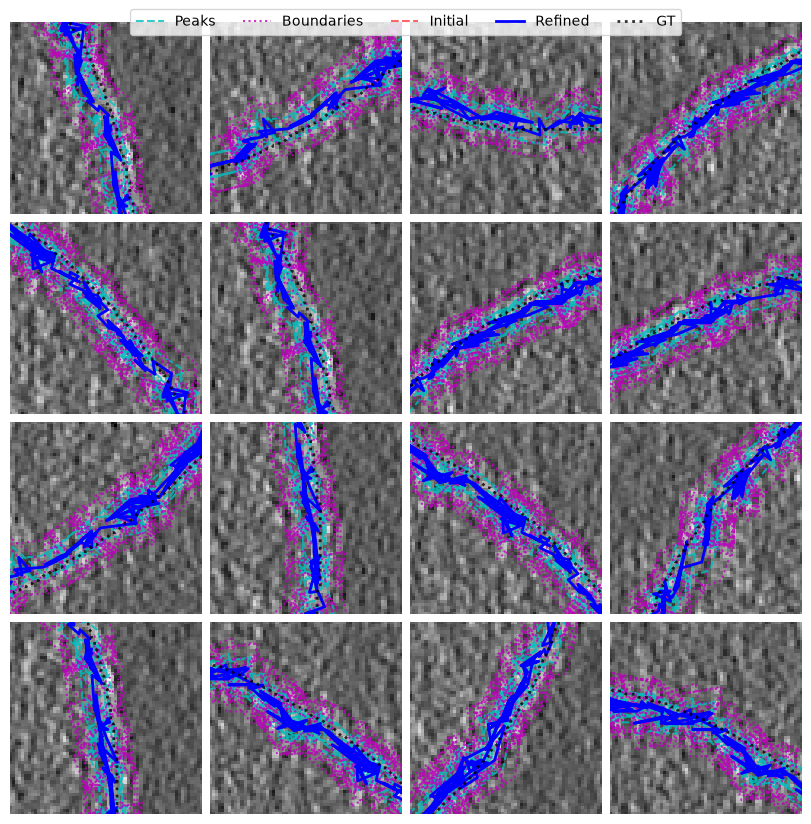

In [19]:
trainer.plot_image()

In [20]:
trainer.trainer.logger.history[-1]

{'step': 4999,
 'data_loss': 0.29701095819473267,
 'correlation_loss': 0.286887526512146,
 'shape_loss': 0.010123422369360924,
 'contour_laplacian_loss': 0.0,
 'edge_length_loss': 0.0,
 'tangential_laplacian_loss': 0.0,
 'normal_consistency_loss': 0.0,
 'contour_anchor_loss': 0.0,
 'anchor_sigma_loss': 0.0,
 'anchor_peak_dist_loss': 0.0,
 'anchor_sigma_ratio_loss': 0.0,
 'anchor_amp_ratio_loss': 0.0,
 'smooth_sigma_loss': 0.0,
 'smooth_peak_dist_loss': 0.0,
 'smooth_sigma_ratio_loss': 0.0,
 'smooth_amp_ratio_loss': 0.0,
 'rbf_weight_decay_loss': 0.0,
 'total_loss': 0.29701095819473267,
 'mean_dist': 2.5878489017486572,
 'epoch': 0}

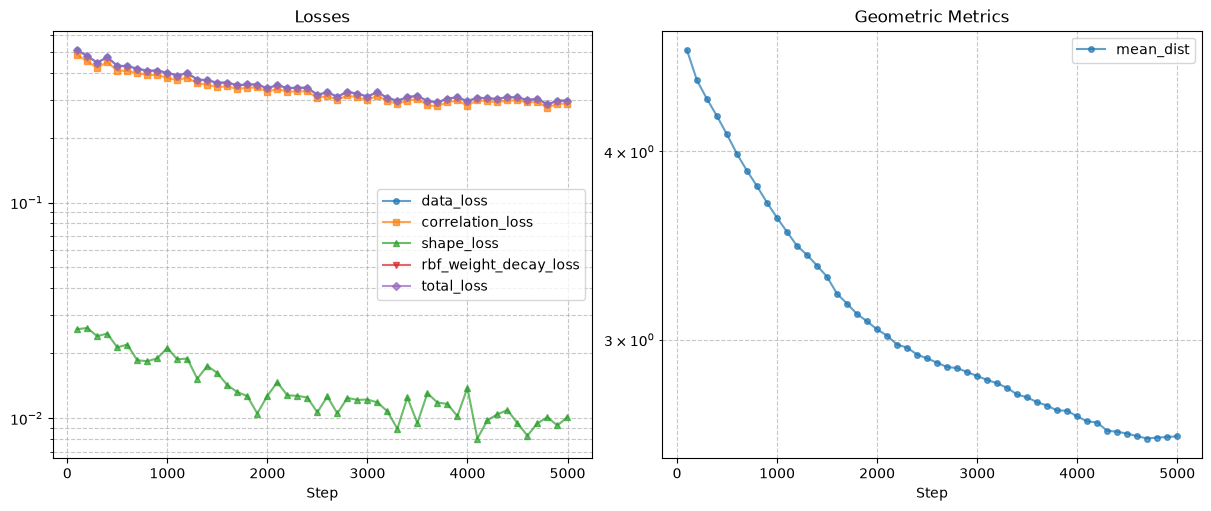

In [21]:
trainer.plot_metrics()

In [22]:
# Evaluate
final_contour = refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics_from_init = hps.compute_contour_metrics(refiner.contour, contour_t)
chamfer_from_init = metrics_from_init["mean_dist"]

In [23]:
chamfer_from_init

2.6665210723876953

In [24]:
template_params = trainer.refiner.template_model.get_params()
(
    template_params["peak_dist"].mean(),
    template_params["peak_dist"].std(),
    template_params["sigma1"].mean(),
    template_params["sigma1"].std(),
)


/var/folders/yn/9_h_16q140xdsd7hwl5c43_h0000gn/T/ipykernel_73930/457710605.py:4: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  template_params["peak_dist"].std(),
/var/folders/yn/9_h_16q140xdsd7hwl5c43_h0000gn/T/ipykernel_73930/457710605.py:6: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  template_params["sigma1"].std(),


(tensor(7.1803, grad_fn=<MeanBackward0>),
 tensor(nan, grad_fn=<StdBackward0>),
 tensor(2.3933, grad_fn=<MeanBackward0>),
 tensor(nan, grad_fn=<StdBackward0>))

THIS IS A DEBUG SETTING AND NEEDS TO BE CHANGED. Context:
Temporary setting for profile norm calculations. Not sure how it works with L1 vs L2.


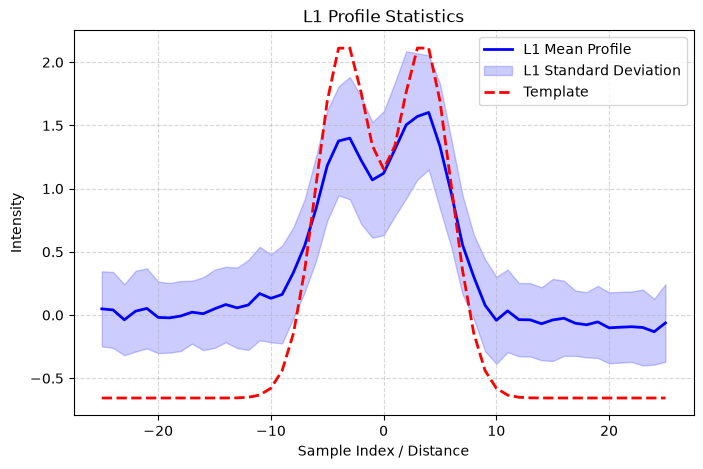

In [25]:
refiner.visualize_profile_statistics(image_t.cpu())


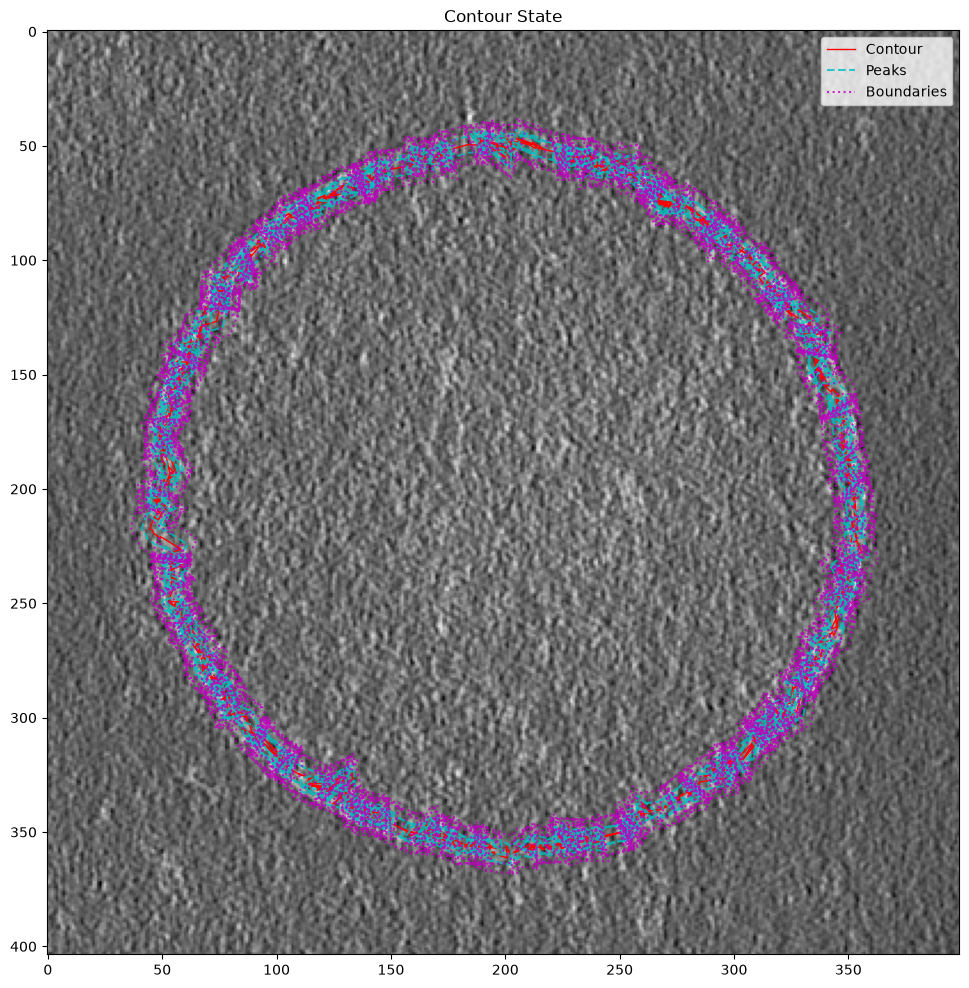

In [26]:
trainer.refiner.visualize_contour(image_t.detach())

### Using global template with tantential laplacian and normal fairing


2026-07-21 15:57:36,740 - INFO - Loading dataset from ../data/2d_training_data_perturbations.pkl
2026-07-21 15:57:36,741 - INFO - Used params: ['learning_rate', 'min_peak_ratio', 'refiner', 'reg_mode', 'shape_loss_weight', 'smoothness_window_size', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_contour_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_smooth_param', 'w_tangential']
2026-07-21 15:57:36,742 - INFO - Unused params: []
2026-07-21 15:57:36,744 - INFO - Creating template model: global
2026-07-21 15:57:36,745 - INFO - Initializing ContourLoss
2026-07-21 15:57:36,746 - INFO - Output directory set to: ../output/verification_test_5A/tang_2_norm_5/2026-07-21_15-57-36
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026

Default params:
ContourRefinerProps(num_steps=2000,
                    learning_rate=0.1,
                    initial_regularization_weights={'anchor_amp_ratio': 0.0,
                                                    'anchor_sigma_ratio': 0.0,
                                                    'contour_anchor': 0.0,
                                                    'contour_laplacian': 0.0,
                                                    'edge_length': 0.0,
                                                    'normal_consistency': 5.0,
                                                    'smooth_amp_ratio': 0.0,
                                                    'smooth_peak_dist': 0.0,
                                                    'smooth_sigma': 0.0,
                                                    'smooth_sigma_ratio': 0.0,
                                                    'tangential_laplacian': 2.0},
                    profile_length=51,
                    pr

2026-07-21 15:58:02,760 - INFO - Final state saved to ../output/verification_test_5A/tang_2_norm_5/2026-07-21_15-57-36/final.pkl


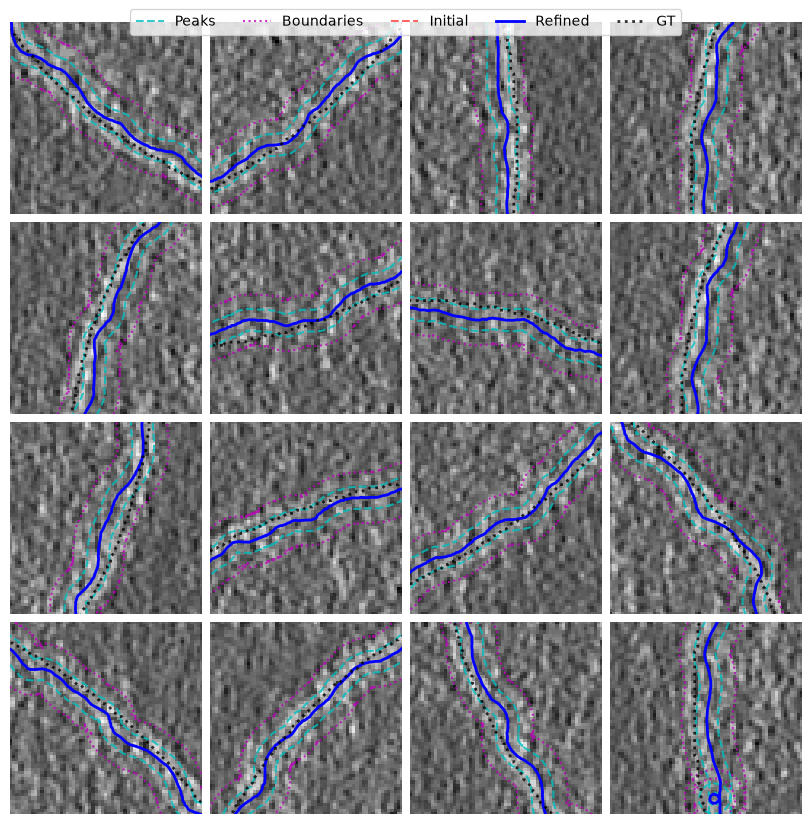

{'anchor_amp_ratio_loss': 0.0,
 'anchor_peak_dist_loss': 0.0,
 'anchor_sigma_loss': 0.0,
 'anchor_sigma_ratio_loss': 0.0,
 'contour_anchor_loss': 0.0,
 'contour_laplacian_loss': 0.0,
 'correlation_loss': 0.34974074363708496,
 'data_loss': 0.3746066093444824,
 'edge_length_loss': 0.0,
 'epoch': 0,
 'mean_dist': 2.482649326324463,
 'normal_consistency_loss': 0.037688031792640686,
 'rbf_weight_decay_loss': 0.0,
 'shape_loss': 0.024865875020623207,
 'smooth_amp_ratio_loss': 0.0,
 'smooth_peak_dist_loss': 0.0,
 'smooth_sigma_loss': 0.0,
 'smooth_sigma_ratio_loss': 0.0,
 'step': 4999,
 'tangential_laplacian_loss': 0.01270469930022955,
 'total_loss': 0.4249993562698364}


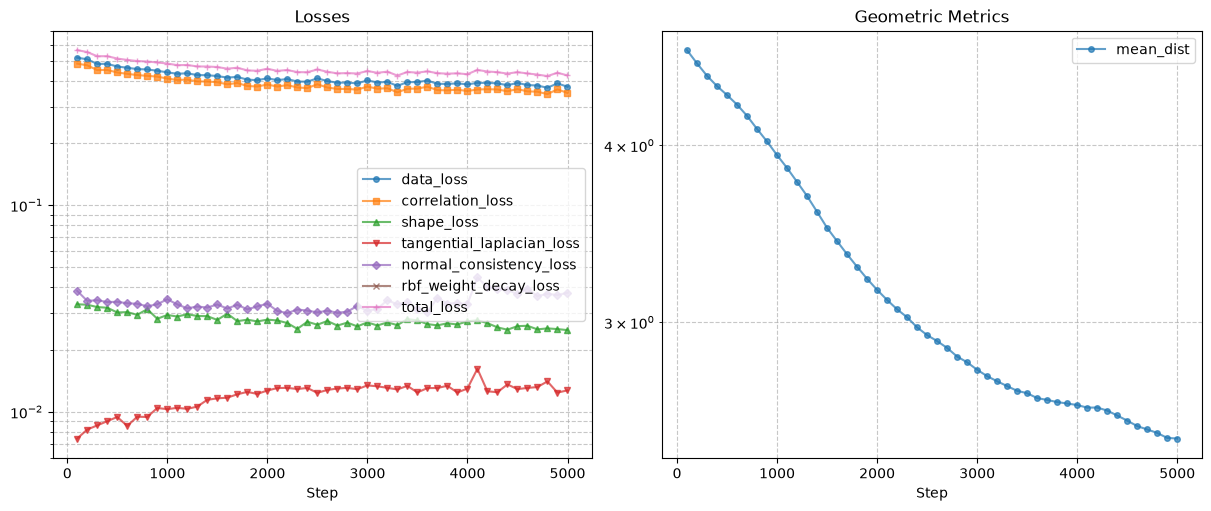

Chamfer from init 2.6744496822357178
Mean Peak Dist: 6.83, Mean Sigma1: 2.28, Mean Sigma2: 2.28
Original Peak Dist: 4.0 Original Sigma1: 0.75


/var/folders/yn/9_h_16q140xdsd7hwl5c43_h0000gn/T/ipykernel_73930/3158984825.py:57: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  template_params["peak_dist"].std(),
/var/folders/yn/9_h_16q140xdsd7hwl5c43_h0000gn/T/ipykernel_73930/3158984825.py:59: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  template_params["sigma1"].std(),


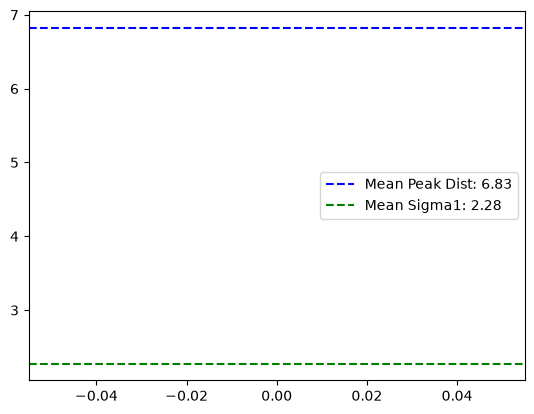

THIS IS A DEBUG SETTING AND NEEDS TO BE CHANGED. Context:
Temporary setting for profile norm calculations. Not sure how it works with L1 vs L2.


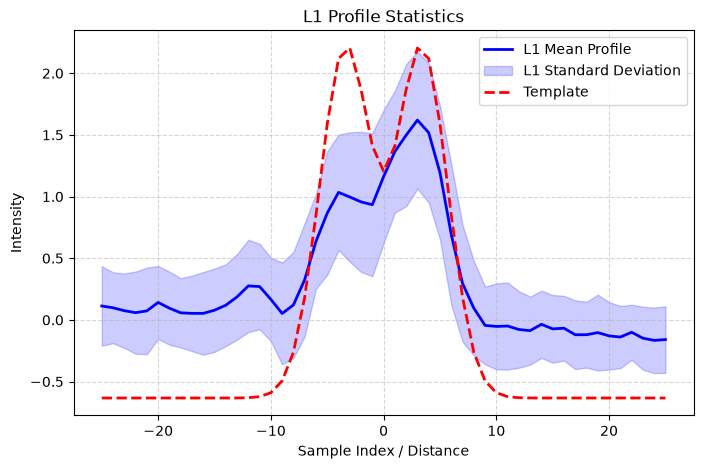

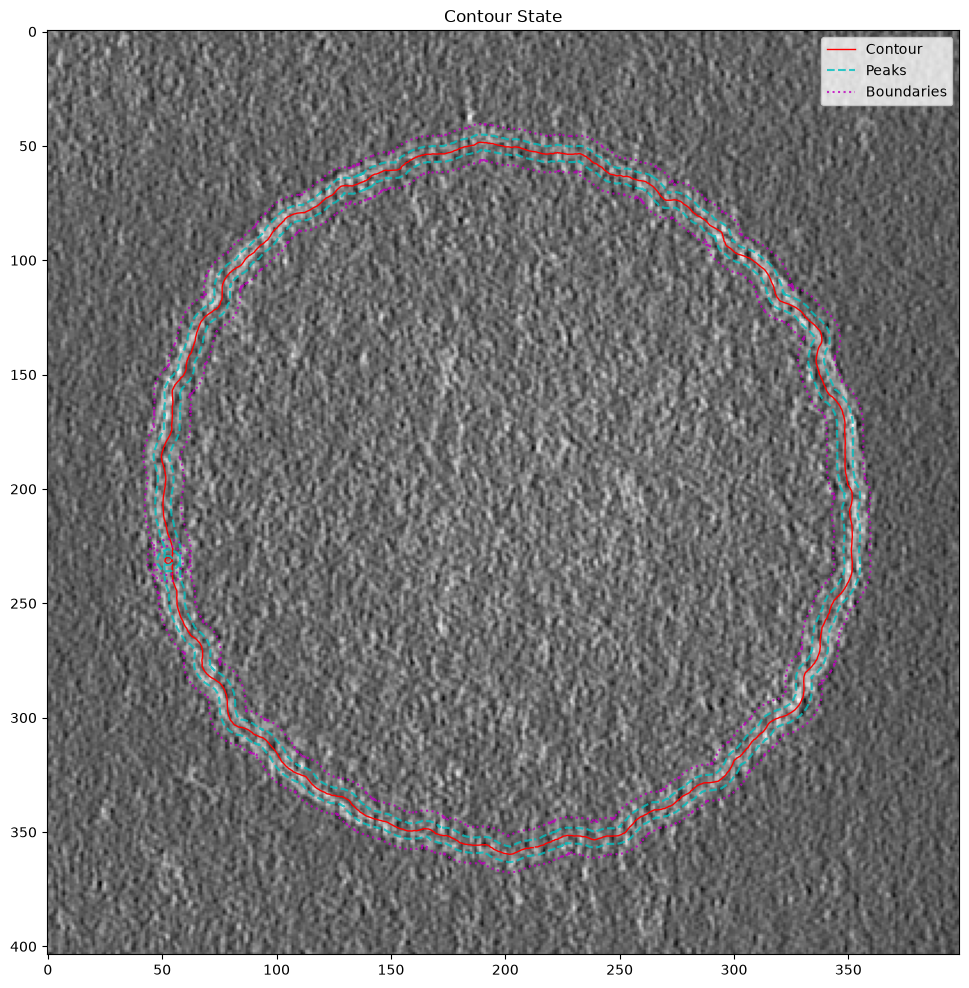

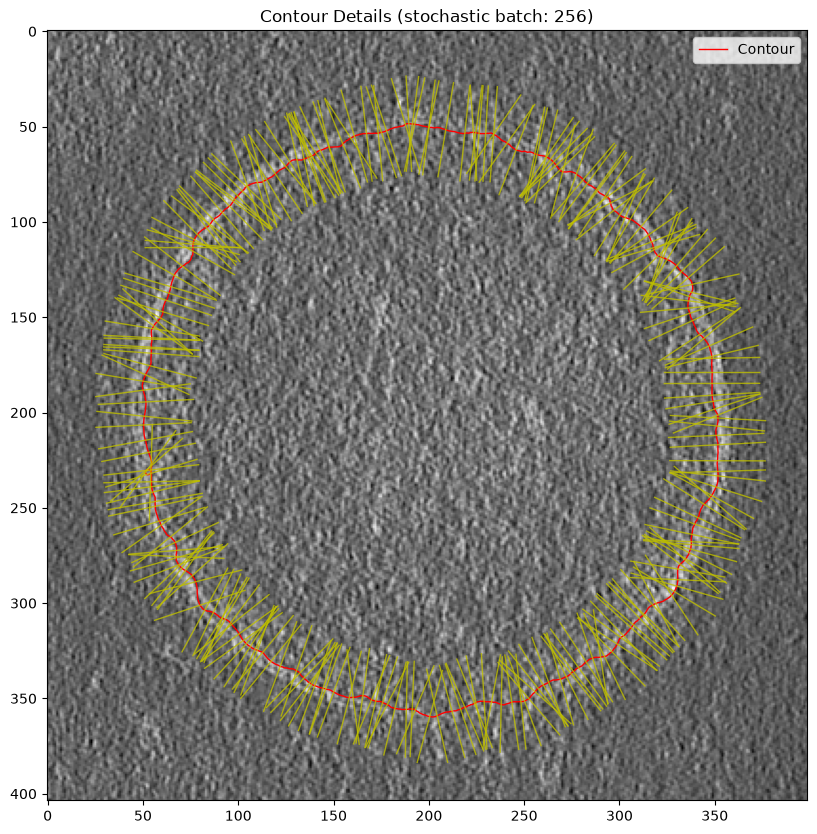

In [36]:
props_dict = {
    "trial_id": "verify_5A",
    "refiner": "vertex",
    "template": "global",
    "symmetric": True,
    "reg_mode": "static",
    "w_laplacian": 0.0,
    "w_edge": 0.0,
    "w_normal": 5.0,
    "w_tangential": 2.0,
    "w_anchor": 0.0,
    "w_smooth_param": 0.0,
    "w_contour_anchor": 0.0,
    "shape_loss_weight": 0.1,
    "learning_rate": 1e-1,
    "smoothness_window_size": 5,
    "min_peak_ratio": 3.0,
}


(
    trainer,
    run_dir,
    refiner_props,
    template_props,
    t_mode,
    image,
    init_contour,
    gt_contour,
    image_t,
    contour_t,
    gt_contour_t,
) = create_trainer_with_config(props_dict=props_dict, output_subdir_name="tang_2_norm_5")
trainer.fit(5000)
display(trainer.plot_image())

pprint(trainer.trainer.logger.history[-1])
fig = trainer.plot_metrics()
display(fig)

# Evaluate
final_contour = trainer.refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics_from_init = hps.compute_contour_metrics(trainer.refiner.contour, contour_t)
chamfer_from_init = metrics_from_init["mean_dist"]
print("Chamfer from init", chamfer_from_init)
tmp_coords = trainer.refiner.contour
tmp_coords = tmp_coords.detach().cpu()
template_params = trainer.refiner.template_model.get_params(coordinates=tmp_coords)
(
    template_params["peak_dist"].mean(),
    template_params["peak_dist"].std(),
    template_params["sigma1"].mean(),
    template_params["sigma1"].std(),
)

mean_peak_dist = template_params["peak_dist"].detach().numpy().mean()
mean_sigma1 = template_params["sigma1"].detach().numpy().mean()
mean_sigma2 = template_params["sigma2"].detach().numpy().mean()

print(
    f"Mean Peak Dist: {mean_peak_dist:.2f}, Mean Sigma1: {mean_sigma1:.2f}, Mean Sigma2: {mean_sigma2:.2f}"
)
print(f"Original Peak Dist: {template_props.peak_dist} Original Sigma1: {template_props.sigma}")

plt.plot(template_params["peak_dist"].detach().numpy())
plt.plot(template_params["sigma1"].detach().numpy())
plt.axhline(
    y=mean_peak_dist, color="b", linestyle="dashed", label=f"Mean Peak Dist: {mean_peak_dist:.2f}"
)
plt.axhline(y=mean_sigma1, color="g", linestyle="dashed", label=f"Mean Sigma1: {mean_sigma1:.2f}")
plt.legend()
plt.show()


tmp_profiles, *_ = trainer.refiner.sample_image_features(image_t)
tmp_profiles = tmp_profiles.detach()
trainer.refiner.visualize_profile_statistics(image_t.cpu())
plt.show()
trainer.refiner.visualize_contour(image_t.detach())
vis.plot_contour_normals(image_t, tmp_coords.detach().numpy())
plt.show()

In [42]:
## Verifying a per-vertex template with tangential and normal smoothing. Adjusting smoothing and other weights to make the profiles resonable

2026-07-21 16:25:20,384 - INFO - Loading dataset from ../data/2d_training_data_perturbations.pkl
2026-07-21 16:25:20,386 - INFO - Used params: ['learning_rate', 'min_peak_ratio', 'refiner', 'reg_mode', 'shape_loss_weight', 'smoothness_window_size', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_contour_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_smooth_param', 'w_tangential']
2026-07-21 16:25:20,387 - INFO - Unused params: []
2026-07-21 16:25:20,389 - INFO - Creating template model: per_point
2026-07-21 16:25:20,390 - INFO - Initializing ContourLoss
2026-07-21 16:25:20,391 - INFO - Output directory set to: ../output/verification_test_5A/tang_2_norm_5_per_point/2026-07-21_16-25-20
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments p

Default params:
ContourRefinerProps(num_steps=2000,
                    learning_rate=0.1,
                    initial_regularization_weights={'anchor_amp_ratio': 0.0,
                                                    'anchor_sigma_ratio': 0.0,
                                                    'contour_anchor': 0.0,
                                                    'contour_laplacian': 0.0,
                                                    'edge_length': 0.0,
                                                    'normal_consistency': 50.0,
                                                    'smooth_amp_ratio': 50.0,
                                                    'smooth_peak_dist': 50.0,
                                                    'smooth_sigma': 50.0,
                                                    'smooth_sigma_ratio': 50.0,
                                                    'tangential_laplacian': 5.0},
                    profile_length=51,
                 

2026-07-21 16:25:49,699 - INFO - Final state saved to ../output/verification_test_5A/tang_2_norm_5_per_point/2026-07-21_16-25-20/final.pkl


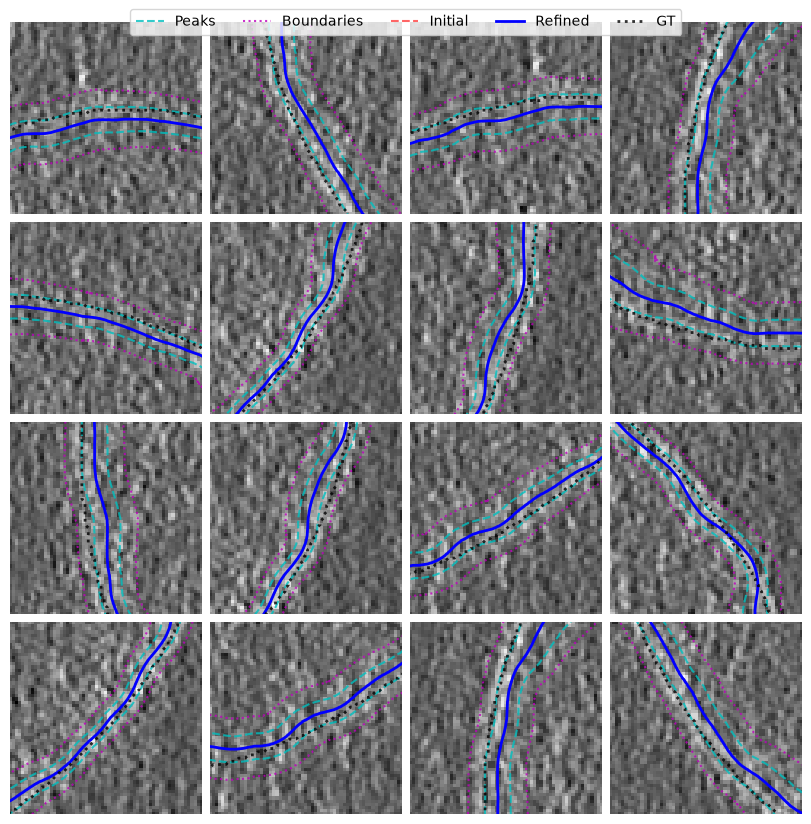

{'anchor_amp_ratio_loss': 0.0,
 'anchor_peak_dist_loss': 0.0,
 'anchor_sigma_loss': 0.0,
 'anchor_sigma_ratio_loss': 0.0,
 'contour_anchor_loss': 0.0,
 'contour_laplacian_loss': 0.0,
 'correlation_loss': 0.385177344083786,
 'data_loss': 0.4222981035709381,
 'edge_length_loss': 0.0,
 'epoch': 0,
 'mean_dist': 3.4065418243408203,
 'normal_consistency_loss': 0.03603499010205269,
 'rbf_weight_decay_loss': 0.0,
 'shape_loss': 0.0371207669377327,
 'smooth_amp_ratio_loss': 0.0,
 'smooth_peak_dist_loss': 0.005391308106482029,
 'smooth_sigma_loss': 0.0038071968592703342,
 'smooth_sigma_ratio_loss': 0.0,
 'step': 4999,
 'tangential_laplacian_loss': 0.012528286315500736,
 'total_loss': 0.4800598919391632}


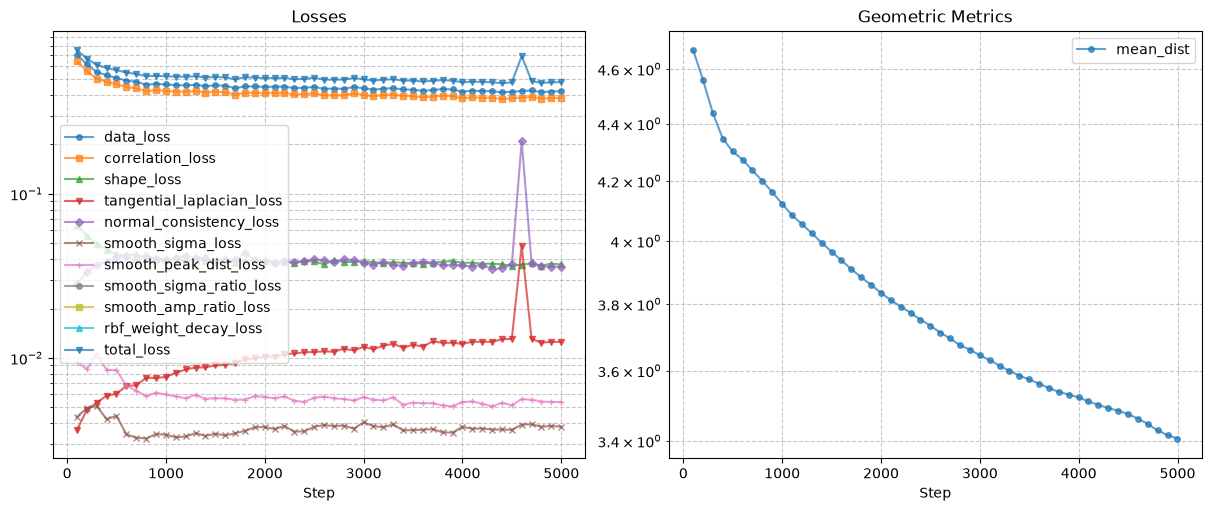

Chamfer from init 1.7752540111541748
Mean Peak Dist: 7.74, Mean Sigma1: 2.46, Mean Sigma2: 2.46
Original Peak Dist: 4.0 Original Sigma1: 0.75


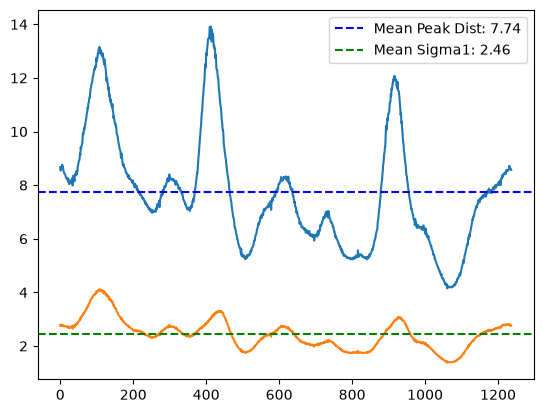

THIS IS A DEBUG SETTING AND NEEDS TO BE CHANGED. Context:
Temporarily using L2 norm for averaging template profiles for visualization.
THIS IS A DEBUG SETTING AND NEEDS TO BE CHANGED. Context:
Temporary setting for profile norm calculations. Not sure how it works with L1 vs L2.


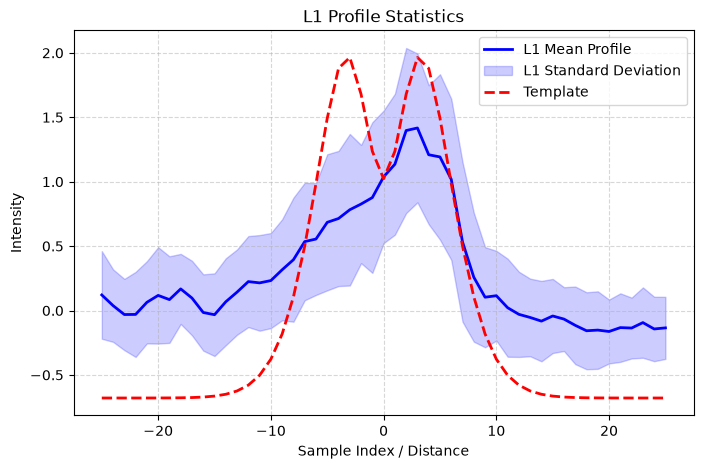

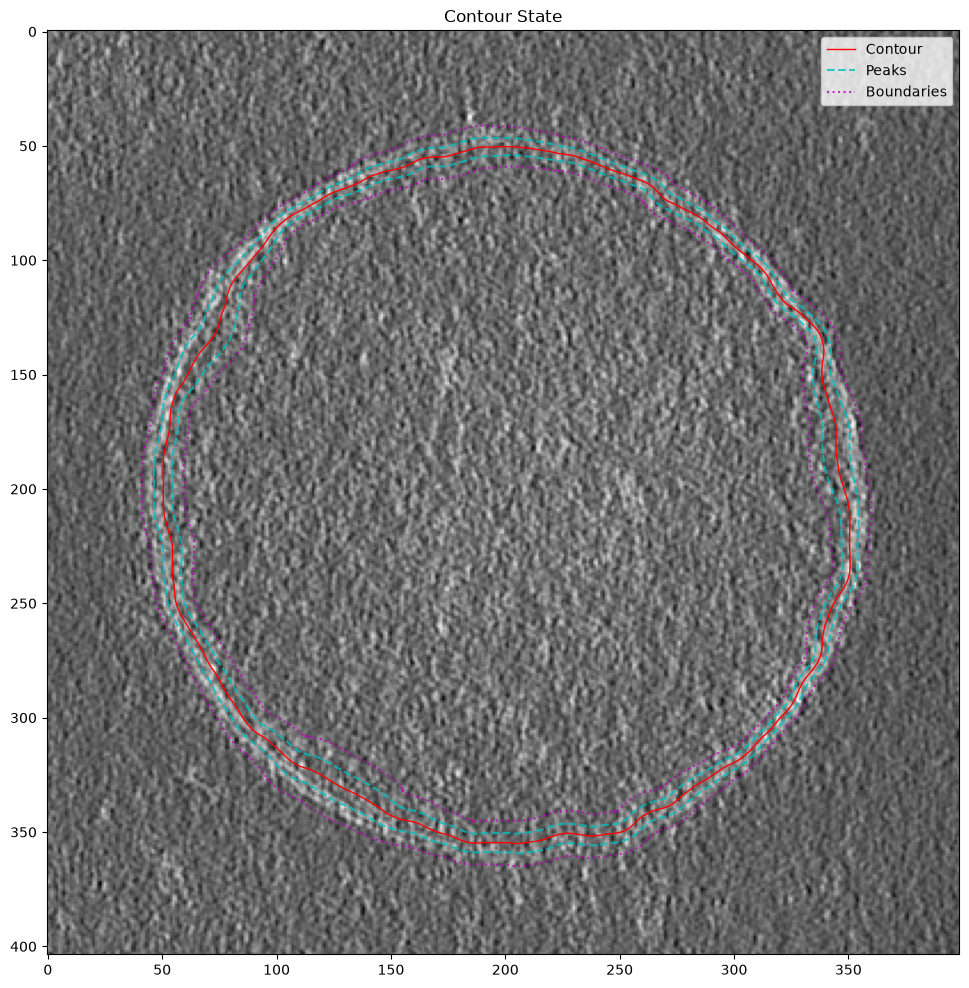

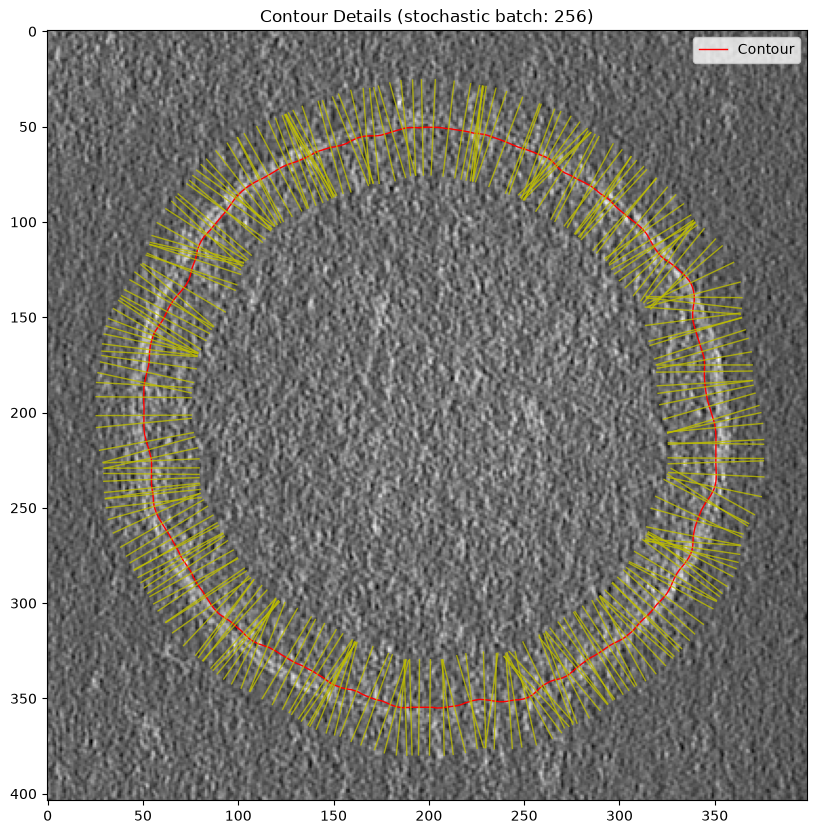

In [48]:
props_dict = {
    "trial_id": "verify_5A",
    "refiner": "vertex",
    "template": "per_point",
    "symmetric": True,
    "reg_mode": "static",
    "w_laplacian": 0.0,
    "w_edge": 0.0,
    "w_normal": 50.0,
    "w_tangential": 5.0,
    "w_anchor": 0.0,
    "w_smooth_param": 50.0,
    "w_contour_anchor": 0.0,
    "shape_loss_weight": 0.1,
    "learning_rate": 1e-1,
    "smoothness_window_size": 15,
    "min_peak_ratio": 3.0,
}


(
    trainer,
    run_dir,
    refiner_props,
    template_props,
    t_mode,
    image,
    init_contour,
    gt_contour,
    image_t,
    contour_t,
    gt_contour_t,
) = create_trainer_with_config(props_dict=props_dict, output_subdir_name="tang_2_norm_5_per_point")
trainer.fit(5000)
display(trainer.plot_image())

pprint(trainer.trainer.logger.history[-1])
fig = trainer.plot_metrics()
display(fig)

# Evaluate
final_contour = trainer.refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics_from_init = hps.compute_contour_metrics(trainer.refiner.contour, contour_t)
chamfer_from_init = metrics_from_init["mean_dist"]
print("Chamfer from init", chamfer_from_init)
tmp_coords = trainer.refiner.contour
tmp_coords = tmp_coords.detach().cpu()
template_params = trainer.refiner.template_model.get_params(coordinates=tmp_coords)
(
    template_params["peak_dist"].mean(),
    template_params["peak_dist"].std(),
    template_params["sigma1"].mean(),
    template_params["sigma1"].std(),
)

mean_peak_dist = template_params["peak_dist"].detach().numpy().mean()
mean_sigma1 = template_params["sigma1"].detach().numpy().mean()
mean_sigma2 = template_params["sigma2"].detach().numpy().mean()

print(
    f"Mean Peak Dist: {mean_peak_dist:.2f}, Mean Sigma1: {mean_sigma1:.2f}, Mean Sigma2: {mean_sigma2:.2f}"
)
print(f"Original Peak Dist: {template_props.peak_dist} Original Sigma1: {template_props.sigma}")

plt.plot(template_params["peak_dist"].detach().numpy())
plt.plot(template_params["sigma1"].detach().numpy())
plt.axhline(
    y=mean_peak_dist, color="b", linestyle="dashed", label=f"Mean Peak Dist: {mean_peak_dist:.2f}"
)
plt.axhline(y=mean_sigma1, color="g", linestyle="dashed", label=f"Mean Sigma1: {mean_sigma1:.2f}")
plt.legend()
plt.show()


tmp_profiles, *_ = trainer.refiner.sample_image_features(image_t)
tmp_profiles = tmp_profiles.detach()
trainer.refiner.visualize_profile_statistics(image_t.cpu())
plt.show()
trainer.refiner.visualize_contour(image_t.detach())
vis.plot_contour_normals(image_t, tmp_coords.detach().numpy())
plt.show()

In [49]:
## Verifying a per-vertex from ground truth contour  with tangential and normal smoothing.

In [57]:
default_params = {
    "trial_id": "verify",
    "refiner": "vertex",
    "template": "per_point",
    "symmetric": True,
    "reg_mode": "static",
    "w_laplacian": 0.0,
    "w_edge": 0.0,
    "w_normal": 50.0,
    "w_tangential": 5.0,
    "w_shape": 0.1,
    "w_anchor": 0.0,
    "w_smooth_param": 50.0,
    "min_peak_ratio": 3.0,
}

props_dict = {
    "trial_id": "verify",
    "refiner": "vertex",
    "template": "per_point",
    "symmetric": True,
    "reg_mode": "static",
    "w_laplacian": 0.0,
    "w_edge": 0.0,
    "w_normal": 50.0,
    "w_tangential": 5.0,
    "w_anchor": 0.0,
    "w_smooth_param": 50.0,
    "w_contour_anchor": 0.0,
    "shape_loss_weight": 0.1,
    "learning_rate": 1e-1,
    "smoothness_window_size": 15,
    "min_peak_ratio": 3.0,
}


In [58]:
refiner_props, template_props, t_mode = runner._build_props(props_dict)  # default_params)

2026-07-21 16:34:32,665 - INFO - Used params: ['learning_rate', 'min_peak_ratio', 'refiner', 'reg_mode', 'shape_loss_weight', 'smoothness_window_size', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_contour_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_smooth_param', 'w_tangential']
2026-07-21 16:34:32,666 - INFO - Unused params: []


In [59]:
template_props

TemplateProps(sigma=0.75, peak_dist=4.0, min_peak_ratio=3.0, sigma_ratio=1.0, amp_ratio=1.0, symmetric=True, smoothness_window_size=15)

In [60]:
init_contour = runner.dataset["original"]["contour"]
image = runner.dataset["original"]["image"]
template_model = hps.TemplateModelFactory.create(
    t_mode,
    template_props,
    num_vertices=len(init_contour),
    image_shape=image.shape,
).to(runner.device)

2026-07-21 16:34:36,491 - INFO - Creating template model: per_point


In [61]:
# Prepare Tensors
image_t = torch.from_numpy(image).float().to(runner.device)
contour_t = torch.from_numpy(init_contour).float().to(runner.device)


In [62]:
refiner = hps.ContourRefiner(contour_t, refiner_props, template_model)

2026-07-21 16:34:37,311 - INFO - Initializing ContourLoss


Shape loss weight tensor(0.1000)


In [63]:
refiner.to(device)

ContourRefiner(
  (template_model): PerPointTemplateModel(
    (laplacian_loss_fn): LaplacianSmoothingLoss()
  )
  (loss_fn): ContourLoss(
    (data_loss_fn): BiGaussianLoss()
    (laplacian_loss_fn): LaplacianSmoothingLoss()
    (edge_loss_fn): EdgeLengthConsistencyLoss()
    (spacing_loss_fn): LaplacianSmoothingLoss()
    (fairing_loss_fn): NormalConsistencyLoss()
    (shape_loss_fn): TemplateShapeLoss()
  )
)

In [64]:
run_dir = runner.output_dir / "trials" / f"verification"

config = hps.TrainerConfig(
    output_dir=run_dir,
    image=image,
    gt_contour=None,
    max_steps=2000,
    save_interval=2000,  # Only save at end
    log_interval=500,
    use_tensorboard=False,  # Disable TB to save IO
    save_images=True,
    enable_progress_bar=True,  # Disable progress bar for parallel runs
)

In [65]:
trainer = hps.OptimizationTrainer(refiner, config)

2026-07-21 16:34:40,994 - INFO - Output directory set to: ../output/verification_test_5A/trials/verification/2026-07-21_16-34-40
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [66]:
trainer.fit(2000)

2026-07-21 16:34:42,210 - INFO - Starting fit for 2000 steps.
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/saugat/code/diffmeshopt/output/verification_test_5A/trials/verification/2026-07-21_16-34-40 exists and is not empty.
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 0: 100%|#| 2000/2000 [00:11<00:00, 172.67it/s, v_num=1.0, total_loss=0.434

`Trainer.fit` stopped: `max_steps=2000` reached.


2026-07-21 16:34:53,799 - INFO - Final state saved to ../output/verification_test_5A/trials/verification/2026-07-21_16-34-40/final.pkl


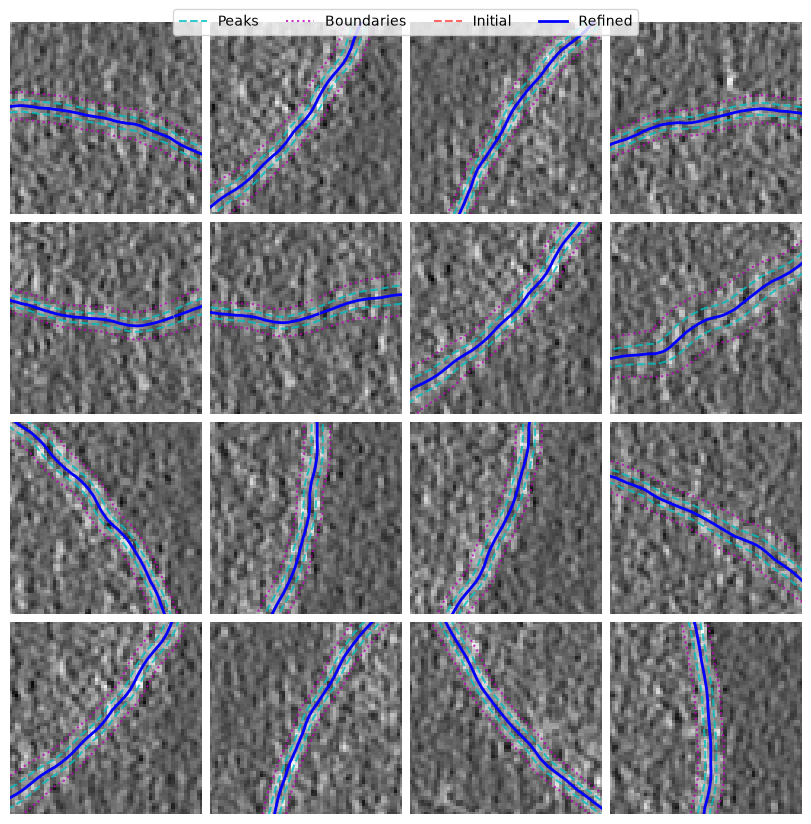

In [67]:
trainer.plot_image()

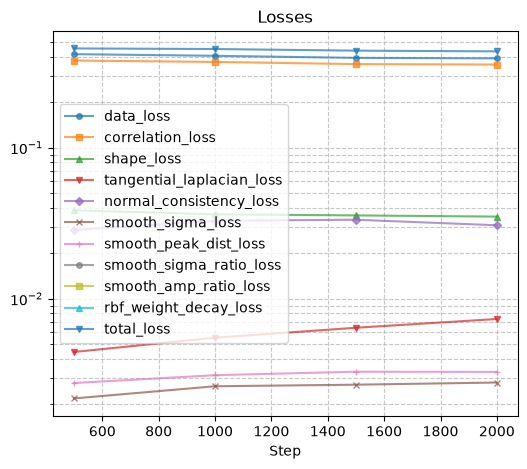

In [68]:
trainer.plot_metrics()

In [69]:
# Evaluate
final_contour = refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics = hps.compute_contour_metrics(refiner.contour, contour_t)
chamfer = metrics["mean_dist"]
chamfer

0.891372561454773

In [70]:
template_params = trainer.refiner.template_model.get_params()
template_params


{'peak_dist': tensor([4.1610, 4.0842, 4.0265,  ..., 4.2689, 4.2244, 4.1994],
        grad_fn=<MulBackward0>),
 'sigma1': tensor([1.3678, 1.3442, 1.3255,  ..., 1.4039, 1.3863, 1.3786],
        grad_fn=<ExpBackward0>),
 'sigma2': tensor([1.3678, 1.3442, 1.3255,  ..., 1.4039, 1.3863, 1.3786],
        grad_fn=<ExpBackward0>),
 'amp1': tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 'amp2': tensor([1., 1., 1.,  ..., 1., 1., 1.])}

THIS IS A DEBUG SETTING AND NEEDS TO BE CHANGED. Context:
Temporarily using L2 norm for averaging template profiles for visualization.
THIS IS A DEBUG SETTING AND NEEDS TO BE CHANGED. Context:
Temporary setting for profile norm calculations. Not sure how it works with L1 vs L2.


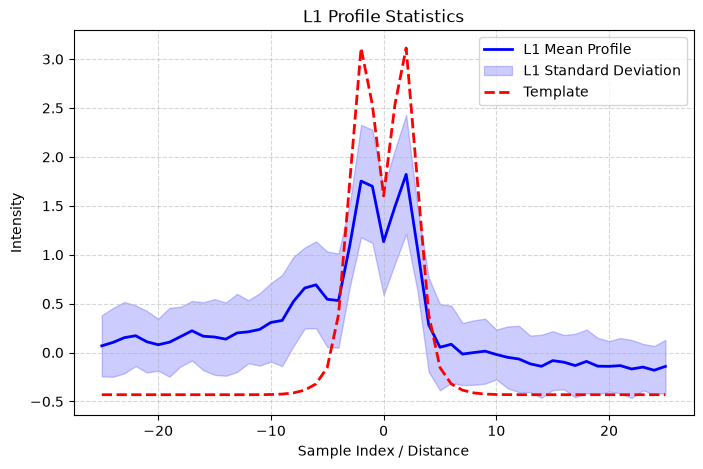

In [71]:
refiner.visualize_profile_statistics(image_t.cpu())

Mean Peak Dist: 3.89, Mean Sigma1: 1.23, Mean Sigma2: 1.23
Original Peak Dist: 4.0 Original Sigma1: 0.75


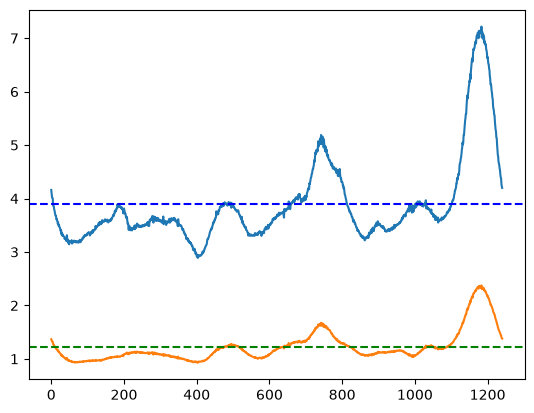

In [72]:
mean_peak_dist = template_params["peak_dist"].detach().numpy().mean()
mean_sigma1 = template_params["sigma1"].detach().numpy().mean()
mean_sigma2 = template_params["sigma2"].detach().numpy().mean()

print(
    f"Mean Peak Dist: {mean_peak_dist:.2f}, Mean Sigma1: {mean_sigma1:.2f}, Mean Sigma2: {mean_sigma2:.2f}"
)
print(f"Original Peak Dist: {template_props.peak_dist} Original Sigma1: {template_props.sigma}")

plt.plot(template_params["peak_dist"].detach().numpy())
plt.plot(template_params["sigma1"].detach().numpy())
plt.axhline(
    y=mean_peak_dist,
    color="b",
    linestyle="dashed",
)
plt.axhline(
    y=mean_sigma1,
    color="g",
    linestyle="dashed",
)
plt.show()

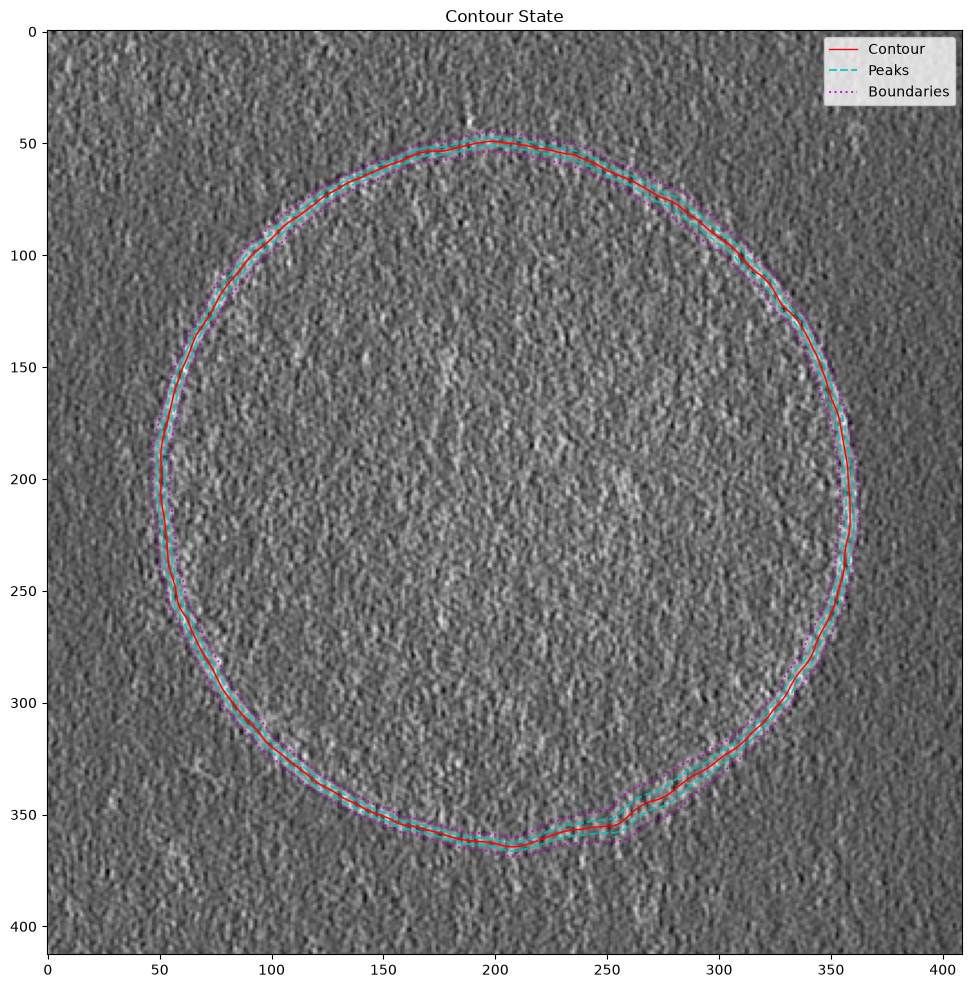

In [73]:
trainer.refiner.visualize_contour(image_t.detach())